# River networks code

The Python code converts the extracted river-channel network into a directed graph using NetworkX. The processed river channels are represented as continuous linear paths, which are first simplified through thresholding and skeletonization using scikit-image. The code then identifies and generates nodes from the processed channel network and establishes edges connecting these nodes along the river channels. Each edge is assigned a direction corresponding to the inferred upstream-to-downstream flow direction, producing a directed graph that represents the connectivity and flow structure of the river network. NetworkX is subsequently used to calculate in-degree and out-degree, degree centrality, closeness centrality, clustering coefficient, and betweenness centrality for the resulting directed network. 

Versions used are as follows: 
- matplotlib 3.5.1
- NetworkX 2.7.1
- NumPy 1.21.5
- Python 3.9.12 or 3.10
- SciPy 1.10.1
- Scikit-Image 0.19.2
- Skimage submodules 0.19.2


In [51]:
# Imports

from skimage import io, color, filters, morphology
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import sys
import scipy
import skimage

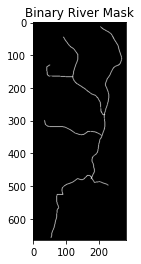

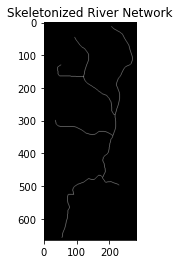

In [52]:
# Converts the image to grayscale and applies Otsu’s thresholding to isolate the river network as a binary mask. 

img = io.imread("188.png")  # replace with your .png file

# Keep only the first 3 channels (RGB)
img_rgb = img[:, :, :3]

gray = color.rgb2gray(img_rgb) 

# Apply thresholding (Otsu's method automatically finds cutoff)
thresh = filters.threshold_otsu(gray)
binary = gray < thresh  # river (dark) = True, background = False

plt.imshow(binary, cmap='gray')
plt.title("Binary River Mask")
plt.show()
skeleton = morphology.skeletonize(binary)    # Reduce river channels to single pixel wide lines
plt.imshow(skeleton, cmap='gray')
plt.title("Skeletonized River Network")
plt.show()
G = nx.Graph()
coords = np.argwhere(skeleton)

In [53]:
# 2D convolution filter is used to isolate channel junctions (intersections) and endpoints to serve as network nodes

from scipy.signal import convolve2d

kernel = np.array([[1,1,1],
                   [1,10,1],
                   [1,1,1]])

neighbors = convolve2d(skeleton.astype(int), kernel, mode='same')

# Endpoints and junctions
node_mask = (neighbors == 11) | (neighbors >= 13)

node_coords = np.column_stack(np.where(node_mask))

In [54]:
# Initializes an undirected NetworkX graph and populates it with the identified nodes. 

# Example: node coordinates (y, x) from skeleton/image
# node_coords = [(y1, x1), (y2, x2), ...]

G = nx.Graph()

# Add nodes with labels
for i, (y, x) in enumerate(node_coords):
    G.add_node(i, pos=(x, y), label=f"N{i}")

print("Original nodes:", G.nodes(data=True))

# -----------------------------
# Sensitivity filter: remove clustered/false nodes
# -----------------------------

def remove_clustered_nodes(G, distance_threshold=5):
    """
    Removes nodes that are too close to each other (clustered nodes),
    keeping only one representative node per cluster.
    
    distance_threshold: max distance (pixels) to consider nodes as "clustered"
    """
    nodes = list(G.nodes)
    positions = np.array([G.nodes[n]['pos'] for n in nodes])
    
    keep_nodes = []
    removed_nodes = set()
    
    for i, n1 in enumerate(nodes):
        if n1 in removed_nodes:
            continue
        pos1 = positions[i]
        # Compare to all other nodes
        for j, n2 in enumerate(nodes):
            if n2 == n1 or n2 in removed_nodes:
                continue
            pos2 = positions[j]
            dist = np.linalg.norm(np.array(pos1) - np.array(pos2))
            if dist < distance_threshold:
                # Remove the second node
                removed_nodes.add(n2)
        keep_nodes.append(n1)
    
    # Create a new graph with only the filtered nodes
    G_filtered = G.subgraph(keep_nodes).copy()
    return G_filtered

# Apply sensitivity filter
G_filtered = remove_clustered_nodes(G, distance_threshold=8) # Merges redundant or closely clusted nodes

print("Filtered nodes:", G_filtered.nodes(data=True))


Original nodes: [(0, {'pos': (204, 13), 'label': 'N0'}), (1, {'pos': (92, 46), 'label': 'N1'}), (2, {'pos': (51, 130), 'label': 'N2'}), (3, {'pos': (120, 165), 'label': 'N3'}), (4, {'pos': (119, 166), 'label': 'N4'}), (5, {'pos': (120, 166), 'label': 'N5'}), (6, {'pos': (120, 167), 'label': 'N6'}), (7, {'pos': (214, 282), 'label': 'N7'}), (8, {'pos': (215, 282), 'label': 'N8'}), (9, {'pos': (215, 283), 'label': 'N9'}), (10, {'pos': (34, 299), 'label': 'N10'}), (11, {'pos': (208, 346), 'label': 'N11'}), (12, {'pos': (177, 473), 'label': 'N12'}), (13, {'pos': (227, 497), 'label': 'N13'}), (14, {'pos': (89, 524), 'label': 'N14'}), (15, {'pos': (88, 525), 'label': 'N15'}), (16, {'pos': (89, 525), 'label': 'N16'}), (17, {'pos': (54, 657), 'label': 'N17'})]
Filtered nodes: [(0, {'pos': (204, 13), 'label': 'N0'}), (1, {'pos': (92, 46), 'label': 'N1'}), (2, {'pos': (51, 130), 'label': 'N2'}), (3, {'pos': (120, 165), 'label': 'N3'}), (7, {'pos': (214, 282), 'label': 'N7'}), (10, {'pos': (34, 29

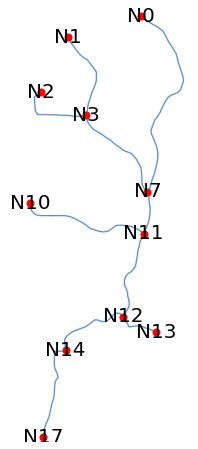

In [55]:
# Overlays the filtered nodes and basic undirected edges onto the original image

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(img, cmap='gray')
ax.axis('off')

pos = nx.get_node_attributes(G_filtered, 'pos')
labels = nx.get_node_attributes(G_filtered, 'label')

nx.draw_networkx_nodes(G_filtered, pos, ax=ax, node_size=50, node_color='red')
nx.draw_networkx_edges(G_filtered, pos, ax=ax)
nx.draw_networkx_labels(G_filtered, pos, labels, ax=ax, font_size=20)

plt.show()

In [56]:
# Stricter distance threshold to finalize the nodes

G_filtered = remove_clustered_nodes(G, distance_threshold=25)

print("Filtered nodes:", G_filtered.nodes(data=True))

G_dir = nx.DiGraph(G_filtered)       # Converts network into a directed graph

G_dir.add_edge(0, 7)  # A → B
G_dir.add_edge(1, 3)  # B → C
G_dir.add_edge(2, 3)  
G_dir.add_edge(3, 7)  
G_dir.add_edge(7,11)  
G_dir.add_edge(10, 11)  
G_dir.add_edge(11, 12)  
G_dir.add_edge(13, 12)  
G_dir.add_edge(12, 14)  
G_dir.add_edge(14, 17)  
print("With edge direction:",G_dir.nodes(data=True))

Filtered nodes: [(0, {'pos': (204, 13), 'label': 'N0'}), (1, {'pos': (92, 46), 'label': 'N1'}), (2, {'pos': (51, 130), 'label': 'N2'}), (3, {'pos': (120, 165), 'label': 'N3'}), (7, {'pos': (214, 282), 'label': 'N7'}), (10, {'pos': (34, 299), 'label': 'N10'}), (11, {'pos': (208, 346), 'label': 'N11'}), (12, {'pos': (177, 473), 'label': 'N12'}), (13, {'pos': (227, 497), 'label': 'N13'}), (14, {'pos': (89, 524), 'label': 'N14'}), (17, {'pos': (54, 657), 'label': 'N17'})]
With edge direction: [(0, {'pos': (204, 13), 'label': 'N0'}), (1, {'pos': (92, 46), 'label': 'N1'}), (2, {'pos': (51, 130), 'label': 'N2'}), (3, {'pos': (120, 165), 'label': 'N3'}), (7, {'pos': (214, 282), 'label': 'N7'}), (10, {'pos': (34, 299), 'label': 'N10'}), (11, {'pos': (208, 346), 'label': 'N11'}), (12, {'pos': (177, 473), 'label': 'N12'}), (13, {'pos': (227, 497), 'label': 'N13'}), (14, {'pos': (89, 524), 'label': 'N14'}), (17, {'pos': (54, 657), 'label': 'N17'})]


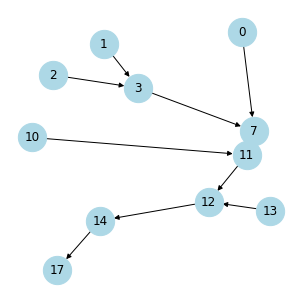

In [57]:
# Plots the directed graph as a standalone diagram
# Arrows to illustrate the established flow direction between the interconnected river nodes

pos = nx.get_node_attributes(G_dir, "pos")

plt.figure(figsize=(4,4))

nx.draw(
    G_dir, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=800,
    arrows=True
)
plt.gca().invert_yaxis()
plt.show()

In [58]:
# Calculates the absolute in-degree (incoming flows) and out-degree (outgoing flows) for individual nodes

G_dir.in_degree("B")   # number of incoming edges
G_dir.out_degree("B")  # number of outgoing edges
avg_in_degree = sum(dict(G_dir.in_degree()).values()) / G.number_of_nodes()
avg_out_degree = sum(dict(G_dir.out_degree()).values()) / G.number_of_nodes()

print ("avg_in_degree:",avg_in_degree)
print ("avg_out_degree:",avg_out_degree)

avg_in_degree: 0.5555555555555556
avg_out_degree: 0.5555555555555556


In [59]:
# Computes the in-degree and out-degree centrality (normalized degree values) for all nodes

in_deg_cent = nx.in_degree_centrality(G_dir)
out_deg_cent = nx.out_degree_centrality(G_dir)

avg_in_deg_cent = sum(in_deg_cent.values()) / len(in_deg_cent)
avg_out_deg_cent = sum(out_deg_cent.values()) / len(out_deg_cent)

print ("in_deg_cent:",in_deg_cent)
print ("out_deg_cent:",out_deg_cent)
print ("avg_in_deg_cent:",avg_in_deg_cent)
print ("avg_out_deg_cent:",avg_out_deg_cent)

in_deg_cent: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.2, 7: 0.2, 10: 0.0, 11: 0.2, 12: 0.2, 13: 0.0, 14: 0.1, 17: 0.1}
out_deg_cent: {0: 0.1, 1: 0.1, 2: 0.1, 3: 0.1, 7: 0.1, 10: 0.1, 11: 0.1, 12: 0.1, 13: 0.1, 14: 0.1, 17: 0.0}
avg_in_deg_cent: 0.09090909090909091
avg_out_deg_cent: 0.0909090909090909


In [60]:
# Calculates the normalized betweenness centrality for the network

bet = nx.betweenness_centrality(G_dir, normalized=True)

avg_bet = sum(bet.values()) / len(bet)
print ("betweenness centrality:",bet)
print ("average betweeness:",avg_bet)

betweenness centrality: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.11111111111111112, 7: 0.17777777777777778, 10: 0.0, 11: 0.2, 12: 0.17777777777777778, 13: 0.0, 14: 0.1, 17: 0.0}
average betweeness: 0.0696969696969697


In [61]:
# Maps the calculated betweenness centrality values to node sizes and colors

# Scale node sizes for visibility
node_sizes = [300 + 4000 * bet[n] for n in G_dir.nodes()]

# Node colors = betweenness
node_colors = [bet[n] for n in G_dir.nodes()]

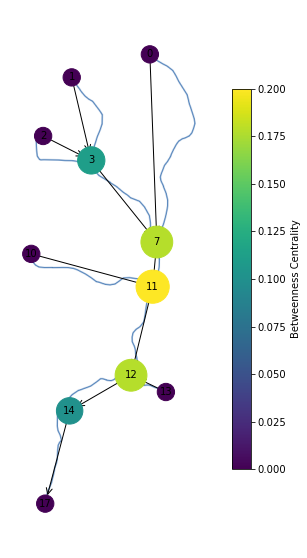

In [41]:
# Draws the directed river network over the original image, scaling and coloring the nodes based on their betweenness centrality

fig, ax = plt.subplots(figsize=(10, 10))

# Optional: background image
ax.imshow(img, cmap="gray")
ax.axis("off")

nx.draw_networkx_edges(
    G_dir,
    pos,
    ax=ax,
    arrowstyle="->",
    arrowsize=15,
    width=1,
    edge_color="black"
)

nodes = nx.draw_networkx_nodes(
    G_dir,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="viridis"
)

nx.draw_networkx_labels(
    G_dir,
    pos,
    ax=ax,
    font_size=10
)

# Colorbar
cbar = plt.colorbar(nodes, ax=ax, shrink=0.7)
cbar.set_label("Betweenness Centrality")

plt.show()

In [42]:
# Computes the closeness centrality for all individual nodes and the network average

clo = nx.closeness_centrality(G_dir)

avg_clo = sum(clo.values()) / len(clo)
print ("closeness centrality:",clo)
print ("average clossness centrality:",avg_clo)

cloesnness centrality: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.2, 7: 0.26666666666666666, 10: 0.0, 11: 0.3, 12: 0.32000000000000006, 13: 0.0, 14: 0.2793103448275862, 17: 0.2564102564102564}
average clossness centrality: 0.14748975162768266


In [43]:
# Finds the largest strongly connected component to calculate network diameter and average path length. 

#### Problem with this part-- not to be utelized for river net

largest_scc = max(nx.strongly_connected_components(G_dir), key=len)
H = G_dir.subgraph(largest_scc)
print(H)
print(largest_scc)
diameter = nx.diameter(H)
avg_path = nx.average_shortest_path_length(H)
print("diameter", diameter)
print("average path:", avg_path)

DiGraph with 1 nodes and 0 edges
{17}
diameter 0
average path: 0


In [44]:
# Identifies the largest weakly connected component, converts it to an undirected subgraph, and calculates the network's diameter and average shortest path length.

## use weakly connected
largest_wcc = max(nx.weakly_connected_components(G_dir), key=len)
H = G_dir.subgraph(largest_wcc)

print(H)
print(largest_wcc)

diameter = nx.diameter(H.to_undirected())
avg_path = nx.average_shortest_path_length(H.to_undirected())

print("diameter:", diameter)
print("average path:", avg_path)

DiGraph with 11 nodes and 10 edges
{0, 1, 2, 3, 7, 10, 11, 12, 13, 14, 17}
diameter: 6
average path: 2.909090909090909


In [45]:
# Calculates the average clustering coefficient to measure the tendency of the network to form closed triangles

#forming of triangles
avg_cluster = nx.average_clustering(G_dir)
print("average clustering:", avg_cluster)

average clustering: 0.0


In [46]:
# Creates a "core" sub-graph by identifying and removing all end nodes—specifically

### REMOVING END NODES:

G_core = G_dir.copy()

for n in list(G_core.nodes()):
    if G_core.in_degree(n) == 0 or G_core.out_degree(n) == 0:
        G_core.remove_node(n)
        
print("Core node (without end nodes):", G_core.nodes(data=True))

Core node (without end nodes): [(12, {'pos': (177, 473), 'label': 'N12'}), (14, {'pos': (89, 524), 'label': 'N14'})]


In [47]:
# Computes the betweenness centrality specifically for the "core" nodes
# Analyzes the network's flow structure without the influence of the terminal endpoints.

#without end nodes

BC=nx.betweenness_centrality(G_core)
#D=nx.diameter(G_core.to_undirected())
#SPL=nx.average_shortest_path_length(G_core.to_undirected())
print("BC:", BC)  
#print("Diameter: ",D)
#print("Shortest Path lenght: ", SPL)

BC: {12: 0.0, 14: 0.0}


In [48]:
# Consolidated summary of all average network-wide metrics

print("-------Average values (river net) ------")
print ("avg_in_degree:",avg_in_degree)
print ("avg_out_degree:",avg_out_degree)
print ("avg_in_deg_cent:",avg_in_deg_cent)
print ("avg_out_deg_cent:",avg_out_deg_cent)
print ("average betweeness:",avg_bet)
print ("average clossness centrality:",avg_clo)
print("diameter:", diameter)
print("average path:", avg_path)
print("average clustering:", avg_cluster)

-------Average values (river net) ------
avg_in_degree: 0.5555555555555556
avg_out_degree: 0.5555555555555556
avg_in_deg_cent: 0.09090909090909091
avg_out_deg_cent: 0.0909090909090909
average betweeness: 0.0696969696969697
average clossness centrality: 0.14748975162768266
diameter: 6
average path: 2.909090909090909
average clustering: 0.0


In [49]:
# Consolidated summary of the individual centrality metrics (in/out degree, betweenness, and closeness) for every node in the network

print("-------river net nodes metrics ------")
print ("in_deg_cent:",in_deg_cent)
print ("out_deg_cent:",out_deg_cent)
print ("betweenness centrality:",bet)
print ("closenness centrality:",clo)

-------river net nodes metrics ------
in_deg_cent: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.2, 7: 0.2, 10: 0.0, 11: 0.2, 12: 0.2, 13: 0.0, 14: 0.1, 17: 0.1}
out_deg_cent: {0: 0.1, 1: 0.1, 2: 0.1, 3: 0.1, 7: 0.1, 10: 0.1, 11: 0.1, 12: 0.1, 13: 0.1, 14: 0.1, 17: 0.0}
betweenness centrality: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.11111111111111112, 7: 0.17777777777777778, 10: 0.0, 11: 0.2, 12: 0.17777777777777778, 13: 0.0, 14: 0.1, 17: 0.0}
closenness centrality: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.2, 7: 0.26666666666666666, 10: 0.0, 11: 0.3, 12: 0.32000000000000006, 13: 0.0, 14: 0.2793103448275862, 17: 0.2564102564102564}


In [50]:
# Outputs the fundamental size and connectivity statistics of the directed graph, including total node count, edge count, and a breakdown of total incoming and outgoing connections

print("Nodes:", G_dir.number_of_nodes())
print("Edges:", G_dir.number_of_edges())
print("In-degree edges:", G_dir.in_degree())
print("Out-degree edges:", G_dir.out_degree())
print("Total in-degree:", sum(dict(G_dir.in_degree()).values()))
print("Total out-degree:", sum(dict(G_dir.out_degree()).values()))

Nodes: 11
Edges: 10
In-degree edges: [(0, 0), (1, 0), (2, 0), (3, 2), (7, 2), (10, 0), (11, 2), (12, 2), (13, 0), (14, 1), (17, 1)]
Out-degree edges: [(0, 1), (1, 1), (2, 1), (3, 1), (7, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (17, 0)]
Total in-degree: 10
Total out-degree: 10
